# Import Library

In [1]:
# =====================================================
# Install Additional Packages (Colab Only)
# =====================================================
!pip install -q gdown sentence-transformers datasets transformers accelerate

# =====================================================
# 1. Basic Libraries & System
# =====================================================
import os
import pandas as pd
import numpy as np
import re
import torch

# =====================================================
# 2. Data Download (Google Drive)
# =====================================================
import gdown

# =====================================================
# 3. Visualization
# =====================================================
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# 4. Scikit-Learn (Baseline ML)
# =====================================================
# Preprocessing & Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# =====================================================
# 5. Sentence Embedding Model
# =====================================================
from sentence_transformers import SentenceTransformer

# =====================================================
# 6. Hugging Face - Fine Tuning (IndoBERT)
# =====================================================
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# =====================================================
# 7. Model Export / Persistence
# =====================================================
import joblib

# Data Preparation

## Load Dataset

In [2]:
# Load From Gdrive
file_id = "1w9f_hnG7VfhHuOqibnp26gkkcKQXWXaq"
download_url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(download_url, "dataset.csv", quiet=False)

df = pd.read_csv("dataset.csv")
df.head()

Downloading...
From: https://drive.google.com/uc?id=1w9f_hnG7VfhHuOqibnp26gkkcKQXWXaq
To: /content/dataset.csv
100%|██████████| 1.26M/1.26M [00:00<00:00, 40.1MB/s]


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Category         5400 non-null   object 
 1   Product Name     5400 non-null   object 
 2   Location         5400 non-null   object 
 3   Price            5400 non-null   int64  
 4   Overall Rating   5400 non-null   float64
 5   Number Sold      5400 non-null   int64  
 6   Total Review     5400 non-null   int64  
 7   Customer Rating  5400 non-null   int64  
 8   Customer Review  5400 non-null   object 
 9   Sentiment        5400 non-null   object 
 10  Emotion          5400 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 464.2+ KB


## Column Selection

In [4]:
# Column Selection

df = df[['Customer Review', 'Emotion']]
df.head()

,Customer Review,Emotion
0,Alhamdulillah berfungsi dengan baik. Packaging...,Happy
1,"barang bagus dan respon cepat, harga bersaing ...",Happy
2,"barang bagus, berfungsi dengan baik, seler ram...",Happy
3,bagus sesuai harapan penjual nya juga ramah. t...,Happy
4,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Happy


## Missing Values and Duplicates

In [5]:
# Handling Missing Values

df.isnull().sum()

,0
Customer Review,0
Emotion,0


In [6]:
# Handling Duplicates

df.duplicated().sum()

np.int64(70)

In [7]:
# Drop Duplicates

df = df.drop_duplicates()

## Text Cleaning

In [8]:
# Text Cleaning

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

df['Customer Review'] = df['Customer Review'].apply(clean_text)

## Label Preparation

In [9]:
# Encoding Labels

le = LabelEncoder()
df['Emotion_Label'] = le.fit_transform(df['Emotion'])

In [10]:
# Label Mapping

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:", label_mapping)

Label Mapping: {'Anger': np.int64(0), 'Fear': np.int64(1), 'Happy': np.int64(2), 'Love': np.int64(3), 'Sadness': np.int64(4)}


In [11]:
# Emotion Distribution After Cleaning

emotion_dist = df['Emotion'].value_counts()
print(emotion_dist)

Emotion
Happy      1754
Sadness    1185
Fear        907
Love        802
Anger       682
Name: count, dtype: int64


# Exploratory Data Analysis

In [12]:
# Total Data

total_data = len(df)
print(f"Total Data: {total_data}")


Total Data: 5330


In [13]:
# Label Distribution

emotion_distribution = df['Emotion'].value_counts()

print("Emotion Distribution:")
print(emotion_distribution)

Emotion Distribution:
Emotion
Happy      1754
Sadness    1185
Fear        907
Love        802
Anger       682
Name: count, dtype: int64


In [14]:
# Example

print("Example:")
display(df[['Customer Review', 'Emotion']].sample(5))

Example:


,Customer Review,Emotion
512,"bau makanan tidak nyaman, dan rasa tidak enak.",Anger
3808,"seller sih ok, pengiriman cepat. barang import...",Fear
2714,"jam tangan nya rusak, ga bisa dipakai sampai r...",Sadness
808,"berfungsi sebagaimana mestinya, mantapp",Happy
3350,barang sampai tapi banyak yang tergores dan pe...,Fear


# Baseline Model

In [15]:
# Train-Test Split

X = df["Customer Review"]
y = df["Emotion_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 4264
Test size: 1066


In [16]:
# TF-IDF Vectorization

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words=None
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
# Logistic Regression
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_reg.fit(X_train_tfidf, y_train)

In [18]:
# Evaluation

y_pred = log_reg.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Baseline Results")
print("Accuracy :", round(accuracy, 4))
print("Macro F1 :", round(macro_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Baseline Results
Accuracy : 0.5976
Macro F1 : 0.5654

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.43      0.43       136
           1       0.41      0.51      0.46       181
           2       0.83      0.73      0.78       351
           3       0.57      0.66      0.61       161
           4       0.58      0.51      0.54       237

    accuracy                           0.60      1066
   macro avg       0.57      0.57      0.57      1066
weighted avg       0.61      0.60      0.60      1066



# Embedding-Based Model

In [ ]:
# Embedding Model

model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

embedder = SentenceTransformer(model_name)

In [ ]:
# Encode train & test text

X_train_embeddings = embedder.encode(
    X_train.tolist(),
    batch_size=32,
    show_progress_bar=True
)

X_test_embeddings = embedder.encode(
    X_test.tolist(),
    batch_size=32,
    show_progress_bar=True
)

print("Embedding shape:", X_train_embeddings.shape)

In [ ]:
# Train LinearSVC

svm_model = LinearSVC(class_weight="balanced")

svm_model.fit(X_train_embeddings, y_train)

In [22]:
# Evaluation

y_pred_embed = svm_model.predict(X_test_embeddings)

accuracy_embed = accuracy_score(y_test, y_pred_embed)
macro_f1_embed = f1_score(y_test, y_pred_embed, average="macro")

print("Embedding Model Results")
print("Accuracy :", round(accuracy_embed, 4))
print("Macro F1 :", round(macro_f1_embed, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_embed))

Embedding Model Results
Accuracy : 0.606
Macro F1 : 0.5659

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.44      0.43       136
           1       0.44      0.41      0.42       181
           2       0.78      0.77      0.78       351
           3       0.58      0.63      0.60       161
           4       0.59      0.59      0.59       237

    accuracy                           0.61      1066
   macro avg       0.56      0.57      0.57      1066
weighted avg       0.61      0.61      0.61      1066



# Fine-Tuned Transformer

In [23]:
# Train Test Split

dataset = Dataset.from_pandas(
    df[['Customer Review', 'Emotion_Label']]
)

dataset = dataset.rename_column("Customer Review", "text")
dataset = dataset.rename_column("Emotion_Label", "label")

dataset = dataset.train_test_split(
    test_size=0.2,
    seed=42
)

In [ ]:
# Tokenization

model_name = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset.set_format("torch")

In [25]:
# Label Mapping Configuration

label2id = {str(k): int(v) for k, v in label_mapping.items()}
id2label = {int(v): str(k) for k, v in label_mapping.items()}

In [ ]:
# Load Pretrained Model (IndoBERT)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5,
    id2label=id2label,
    label2id=label2id
)

In [27]:
# Training Configuration

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True
)

In [28]:
# Evaluation Metrics

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro"),
    }

In [ ]:
# Model Training
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics
)

trainer.train()

In [30]:
# Evaluation

predictions = trainer.predict(tokenized_dataset["test"])

y_pred_bert = np.argmax(predictions.predictions, axis=1)
y_true_bert = predictions.label_ids

bert_accuracy = accuracy_score(y_true_bert, y_pred_bert)
bert_macro_f1 = f1_score(y_true_bert, y_pred_bert, average="macro")

print("BERT Accuracy :", round(bert_accuracy, 4))
print("BERT Macro F1 :", round(bert_macro_f1, 4))

BERT Accuracy : 0.712
BERT Macro F1 : 0.6654


# Confusion Matrix

In [31]:
# Global Confusion Matrix

def plot_confusion_matrix(y_true, y_pred, label_encoder, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

## Baseline Model

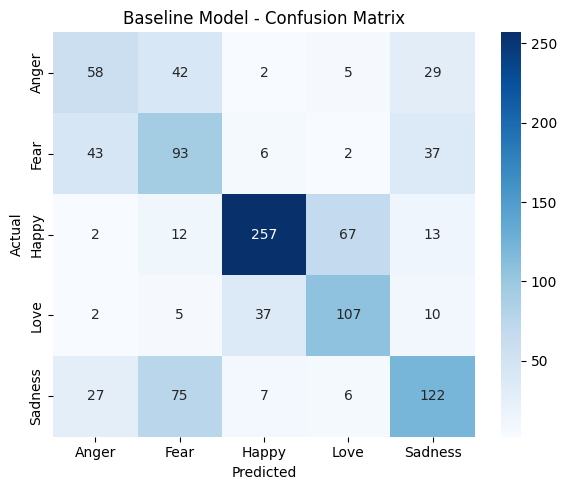

In [32]:
plot_confusion_matrix(
    y_test,
    y_pred,
    le,
    "Baseline Model - Confusion Matrix"
)

## Embedding Model

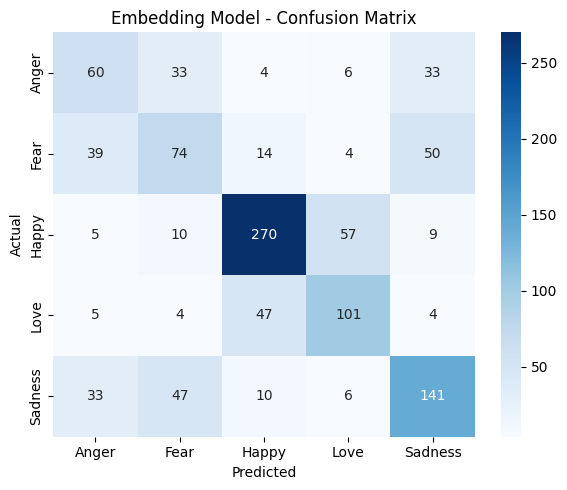

In [33]:
plot_confusion_matrix(
    y_test,
    y_pred_embed,
    le,
    "Embedding Model - Confusion Matrix"
)

## Fine-Tuned Transformer

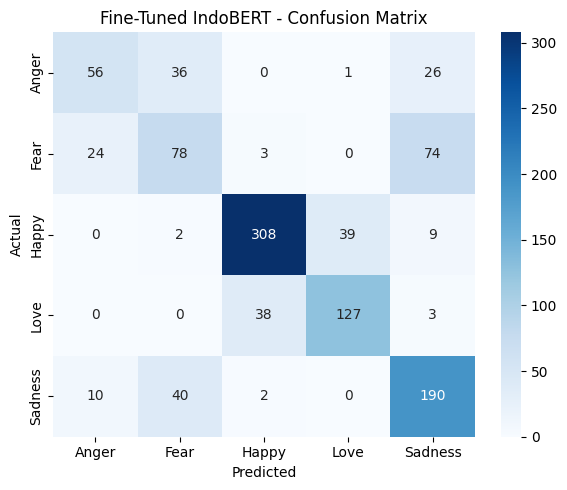

In [34]:
cm = confusion_matrix(y_true_bert, y_pred_bert)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fine-Tuned IndoBERT - Confusion Matrix")
plt.tight_layout()
plt.show()

# Model Comparison

In [35]:
# Baseline

baseline_accuracy = accuracy
baseline_macro_f1 = macro_f1

# Embedding Model

embedding_accuracy = accuracy_embed
embedding_macro_f1 = macro_f1_embed

# Fine-Tuned Transformer
predictions = trainer.predict(tokenized_dataset["test"])

y_pred_bert = np.argmax(predictions.predictions, axis=1)
y_true_bert = predictions.label_ids

bert_accuracy = accuracy_score(y_true_bert, y_pred_bert)
bert_macro_f1 = f1_score(y_true_bert, y_pred_bert, average="macro")

In [36]:
# Model Comparison

comparison_df = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "SentenceTransformer + LinearSVC",
        "Fine-tuned IndoBERT"
    ],
    "Accuracy": [
        baseline_accuracy,
        embedding_accuracy,
        bert_accuracy
    ],
    "Macro F1": [
        baseline_macro_f1,
        embedding_macro_f1,
        bert_macro_f1
    ]
})

comparison_df

,Model,Accuracy,Macro F1
0,TF-IDF + Logistic Regression,0.597561,0.565418
1,SentenceTransformer + LinearSVC,0.606004,0.565901
2,Fine-tuned IndoBERT,0.712008,0.665425


# Save Model

In [37]:
import joblib
import os

# Membuat folder khusus agar rapi (opsional)
os.makedirs('saved_models', exist_ok=True)

# 1. Simpan TF-IDF Vectorizer
joblib.dump(tfidf, 'saved_models/tfidf_vectorizer.pkl')

# 2. Simpan model Logistic Regression
joblib.dump(log_reg, 'saved_models/log_reg_baseline.pkl')

print("✅ TF-IDF Vectorizer dan Model Logistic Regression berhasil disimpan!")

✅ TF-IDF Vectorizer dan Model Logistic Regression berhasil disimpan!


In [38]:
import joblib
import os

# Pastikan folder sudah ada
os.makedirs('saved_models', exist_ok=True)

# 1. Simpan model LinearSVC
joblib.dump(svm_model, 'saved_models/svm_embedding_model.pkl')

# 2. Simpan model SentenceTransformer (Embedder)
# Catatan: Ini akan menyimpan bobot model ke dalam folder lokal.
# Sangat berguna jika aplikasi Streamlit kamu nanti berjalan offline atau ingin proses load lebih cepat.
embedder.save('saved_models/paraphrase-multilingual-MiniLM')

print("✅ Model LinearSVC dan SentenceTransformer berhasil disimpan!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model LinearSVC dan SentenceTransformer berhasil disimpan!


In [39]:
import os

# Tentukan direktori penyimpanan
save_directory = "./saved_models/finetuned_indobert"
os.makedirs(save_directory, exist_ok=True)

# 1. Simpan model terbaik menggunakan trainer
trainer.save_model(save_directory)

# 2. Simpan tokenizer agar bisa memproses teks input baru nanti
tokenizer.save_pretrained(save_directory)

print(f"✅ Model IndoBERT fine-tuned dan tokenizer berhasil disimpan di: {save_directory}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model IndoBERT fine-tuned dan tokenizer berhasil disimpan di: ./saved_models/finetuned_indobert


# Inference

In [40]:
def predict_baseline(text):
    text_tfidf = tfidf.transform([text])
    pred = log_reg.predict(text_tfidf)[0]
    return le.inverse_transform([pred])[0]

# Contoh
print(predict_baseline("Saya sangat kecewa dengan pelayanan ini"))

Sadness


In [41]:
def predict_embedding(text):
    embedding = embedder.encode([text])
    pred = svm_model.predict(embedding)[0]
    return le.inverse_transform([pred])[0]

# Contoh
print(predict_embedding("Saya sangat kecewa dengan pelayanan ini"))

Sadness


In [42]:
def predict_bert(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        prediction = torch.argmax(logits, dim=1).item()

    return le.inverse_transform([prediction])[0]

# Contoh
print(predict_bert("Saya sangat kecewa dengan pelayanan ini"))

Sadness


In [43]:
# Mapping
label_mapping = {'Anger': 0, 'Fear': 1, 'Happy': 2, 'Love': 3, 'Sadness': 4}
id2label_ml = {v: k for k, v in label_mapping.items()}

test_sentences = [
    "Saya sangat senang dengan produk ini",
    "Pelayanannya buruk sekali",
    "Saya takut mencoba lagi",
    "Produk ini biasa saja"
]

print("=== HASIL PREDIKSI 3 MODEL ===\n")

for sentence in test_sentences:
    print(f"Teks: '{sentence}'")

    # 1. Prediksi TF-IDF + Logistic Regression
    tfidf_vec = tfidf.transform([sentence])
    pred_logreg_id = log_reg.predict(tfidf_vec)[0]
    pred_logreg = id2label_ml[int(pred_logreg_id)] # Konversi ID ke String

    # 2. Prediksi SentenceTransformer + LinearSVC
    embed_vec = embedder.encode([sentence])
    pred_svm_id = svm_model.predict(embed_vec)[0]
    pred_svm = id2label_ml[int(pred_svm_id)] # Konversi ID ke String

    # 3. Prediksi Fine-Tuned IndoBERT
    model.eval()
    inputs = tokenizer(sentence, return_tensors="pt", padding=True, truncation=True, max_length=128)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        pred_bert_id = torch.argmax(logits, dim=-1).item()
        pred_bert = id2label[pred_bert_id] # IndoBERT sudah punya id2label sendiri sebelumnya

    # Tampilkan hasil
    print(f"  → LogReg (TF-IDF) : {pred_logreg}")
    print(f"  → LinearSVC (Emb) : {pred_svm}")
    print(f"  → IndoBERT        : {pred_bert}")
    print("-" * 40)

=== HASIL PREDIKSI 3 MODEL ===

Teks: 'Saya sangat senang dengan produk ini'
  → LogReg (TF-IDF) : Love
  → LinearSVC (Emb) : Love
  → IndoBERT        : Happy
----------------------------------------
Teks: 'Pelayanannya buruk sekali'
  → LogReg (TF-IDF) : Anger
  → LinearSVC (Emb) : Anger
  → IndoBERT        : Anger
----------------------------------------
Teks: 'Saya takut mencoba lagi'
  → LogReg (TF-IDF) : Fear
  → LinearSVC (Emb) : Love
  → IndoBERT        : Sadness
----------------------------------------
Teks: 'Produk ini biasa saja'
  → LogReg (TF-IDF) : Fear
  → LinearSVC (Emb) : Happy
  → IndoBERT        : Sadness
----------------------------------------
